<a href="https://colab.research.google.com/github/Swastik058/AI-ML/blob/main/2438468_SwastikAcharya_ComputerVision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Dataset Setup**

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alxmamaev/flowers-recognition")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'flowers-recognition' dataset.
Path to dataset files: /kaggle/input/flowers-recognition


In [ ]:
import os

dataset_path = "/kaggle/input/flowers-recognition/flowers"

classes = os.listdir(dataset_path)
print("Classes:", classes)

for cls in classes:
    count = len(os.listdir(os.path.join(dataset_path, cls)))
    print(f"  {cls}: {count} images")

Classes: ['dandelion', 'daisy', 'sunflower', 'tulip', 'rose']
  dandelion: 1052 images
  daisy: 764 images
  sunflower: 733 images
  tulip: 984 images
  rose: 784 images


**Data Visualization**


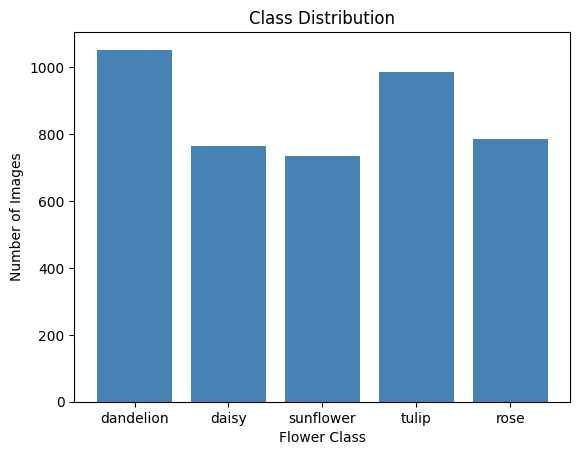

Total images: 4317


In [ ]:
import matplotlib.pyplot as plt

class_counts = {cls: len(os.listdir(os.path.join(dataset_path, cls))) for cls in classes}

plt.bar(class_counts.keys(), class_counts.values(), color='steelblue')
plt.title("Class Distribution")
plt.xlabel("Flower Class")
plt.ylabel("Number of Images")
plt.show()

print("Total images:", sum(class_counts.values()))

**Sample image from each class**


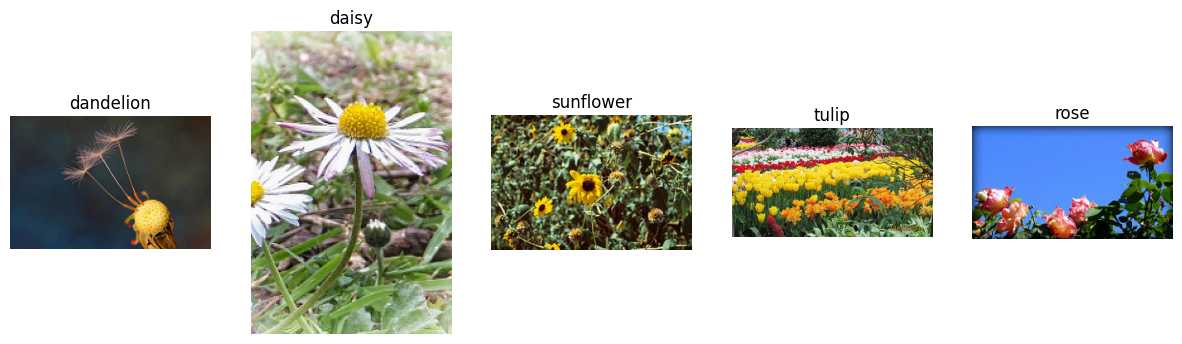

In [ ]:
import matplotlib.image as mpimg

fig, axes = plt.subplots(1, len(classes), figsize=(15, 4))
for ax, cls in zip(axes, classes):
    img_path = os.path.join(dataset_path, cls, os.listdir(os.path.join(dataset_path, cls))[0])
    ax.imshow(mpimg.imread(img_path))
    ax.set_title(cls)
    ax.axis('off')
plt.show()

**Data Preprocessing**

In [ ]:
import os
import shutil
import pandas as pd
from sklearn.model_selection import train_test_split

dataset_path = "/kaggle/input/flowers-recognition/flowers"
output_path = "/content/flowers"

# Build dataframe
filepaths, labels = [], []
for cls in os.listdir(dataset_path):
    cls_folder = os.path.join(dataset_path, cls)
    for img in os.listdir(cls_folder):
        filepaths.append(os.path.join(cls_folder, img))
        labels.append(cls)

df = pd.DataFrame({"filepath": filepaths, "label": labels})

# 70 / 15 / 15 stratified split
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=42)
test_df, val_df   = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42)

print(f"Train: {len(train_df)} | Test: {len(test_df)} | Val: {len(val_df)}")

# Copy files into split folders
def copy_files(dataframe, split_name):
    for _, row in dataframe.iterrows():
        dest_dir = os.path.join(output_path, split_name, row['label'])
        os.makedirs(dest_dir, exist_ok=True)
        shutil.copy(row['filepath'], dest_dir)

copy_files(train_df, "train")
copy_files(test_df,  "test")
copy_files(val_df,   "val")

print("Done! Directory structure:")
for split in ["train", "test", "val"]:
    split_path = os.path.join(output_path, split)
    counts = {cls: len(os.listdir(os.path.join(split_path, cls))) for cls in os.listdir(split_path)}
    print(f"  {split}: {counts}")

Train: 3021 | Test: 648 | Val: 648
Done! Directory structure:
  train: {'tulip': 688, 'rose': 549, 'sunflower': 513, 'dandelion': 736, 'daisy': 535}
  test: {'tulip': 148, 'rose': 118, 'sunflower': 110, 'dandelion': 158, 'daisy': 114}
  val: {'tulip': 148, 'rose': 117, 'sunflower': 110, 'dandelion': 158, 'daisy': 115}


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.15
)
test_val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    "/content/flowers/train",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=42
)

val_gen = test_val_datagen.flow_from_directory(
    "/content/flowers/val",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

test_gen = test_val_datagen.flow_from_directory(
    "/content/flowers/test",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

classes = list(train_gen.class_indices.keys())
print("Classes:", classes)

Found 3021 images belonging to 5 classes.
Found 648 images belonging to 5 classes.
Found 648 images belonging to 5 classes.
Classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


**Dataset Overview & Class Distribution**

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

splits = ["train", "test", "val"]
base_path = "/content/flowers"
classes = sorted(os.listdir(os.path.join(base_path, "train")))

# Count images per class per split
split_counts = {}
for split in splits:
    split_counts[split] = {
        cls: len(os.listdir(os.path.join(base_path, split, cls)))
        for cls in classes
    }

# Print summary
total = 0
for split in splits:
    s = sum(split_counts[split].values())
    total += s
    print(f"{split.upper()}: {s} images → {split_counts[split]}")
print(f"TOTAL: {total} images")

TRAIN: 3021 images → {'daisy': 535, 'dandelion': 736, 'rose': 549, 'sunflower': 513, 'tulip': 688}
TEST: 648 images → {'daisy': 114, 'dandelion': 158, 'rose': 118, 'sunflower': 110, 'tulip': 148}
VAL: 648 images → {'daisy': 115, 'dandelion': 158, 'rose': 117, 'sunflower': 110, 'tulip': 148}
TOTAL: 4317 images


In [ ]:
from PIL import Image
import os

corrupt = []
base_path = "/content/flowers"

for split in ["train", "test", "val"]:
    for cls in os.listdir(os.path.join(base_path, split)):
        cls_path = os.path.join(base_path, split, cls)
        for img_name in os.listdir(cls_path):
            img_path = os.path.join(cls_path, img_name)
            try:
                img = Image.open(img_path)
                img.verify()  # checks file integrity without fully loading
            except Exception as e:
                corrupt.append((img_path, str(e)))

if corrupt:
    print(f"Found {len(corrupt)} corrupt images:")
    for path, err in corrupt:
        print(f"  {path} → {err}")
else:
    print("No corrupt images found.")

No corrupt images found.


**Bar Chart: Class Distribution per Split**

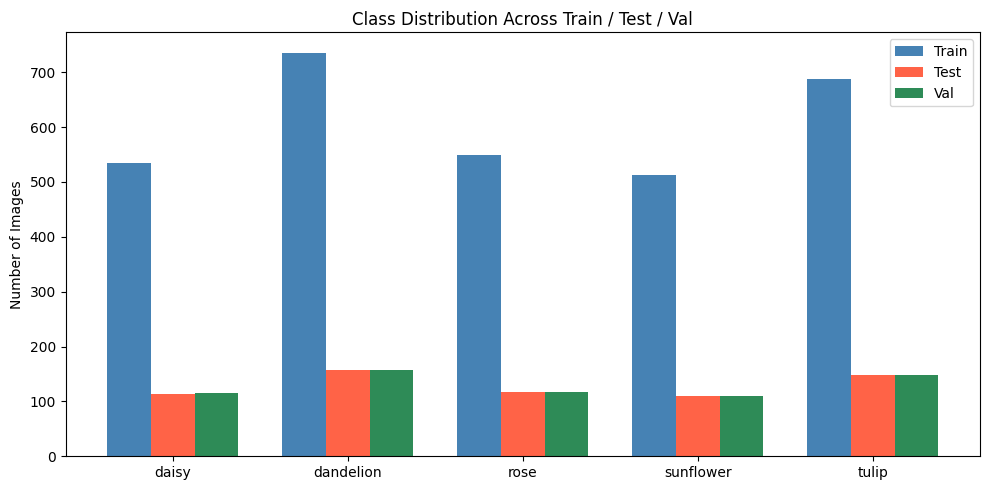

In [ ]:
x = np.arange(len(classes))
width = 0.25
colors = ['steelblue', 'tomato', 'seagreen']

fig, ax = plt.subplots(figsize=(10, 5))
for i, split in enumerate(splits):
    counts = [split_counts[split][cls] for cls in classes]
    ax.bar(x + i * width, counts, width, label=split.capitalize(), color=colors[i])

ax.set_xticks(x + width)
ax.set_xticklabels(classes)
ax.set_title("Class Distribution Across Train / Test / Val")
ax.set_ylabel("Number of Images")
ax.legend()
plt.tight_layout()
plt.show()

**Sample image from each class(Train Set)**

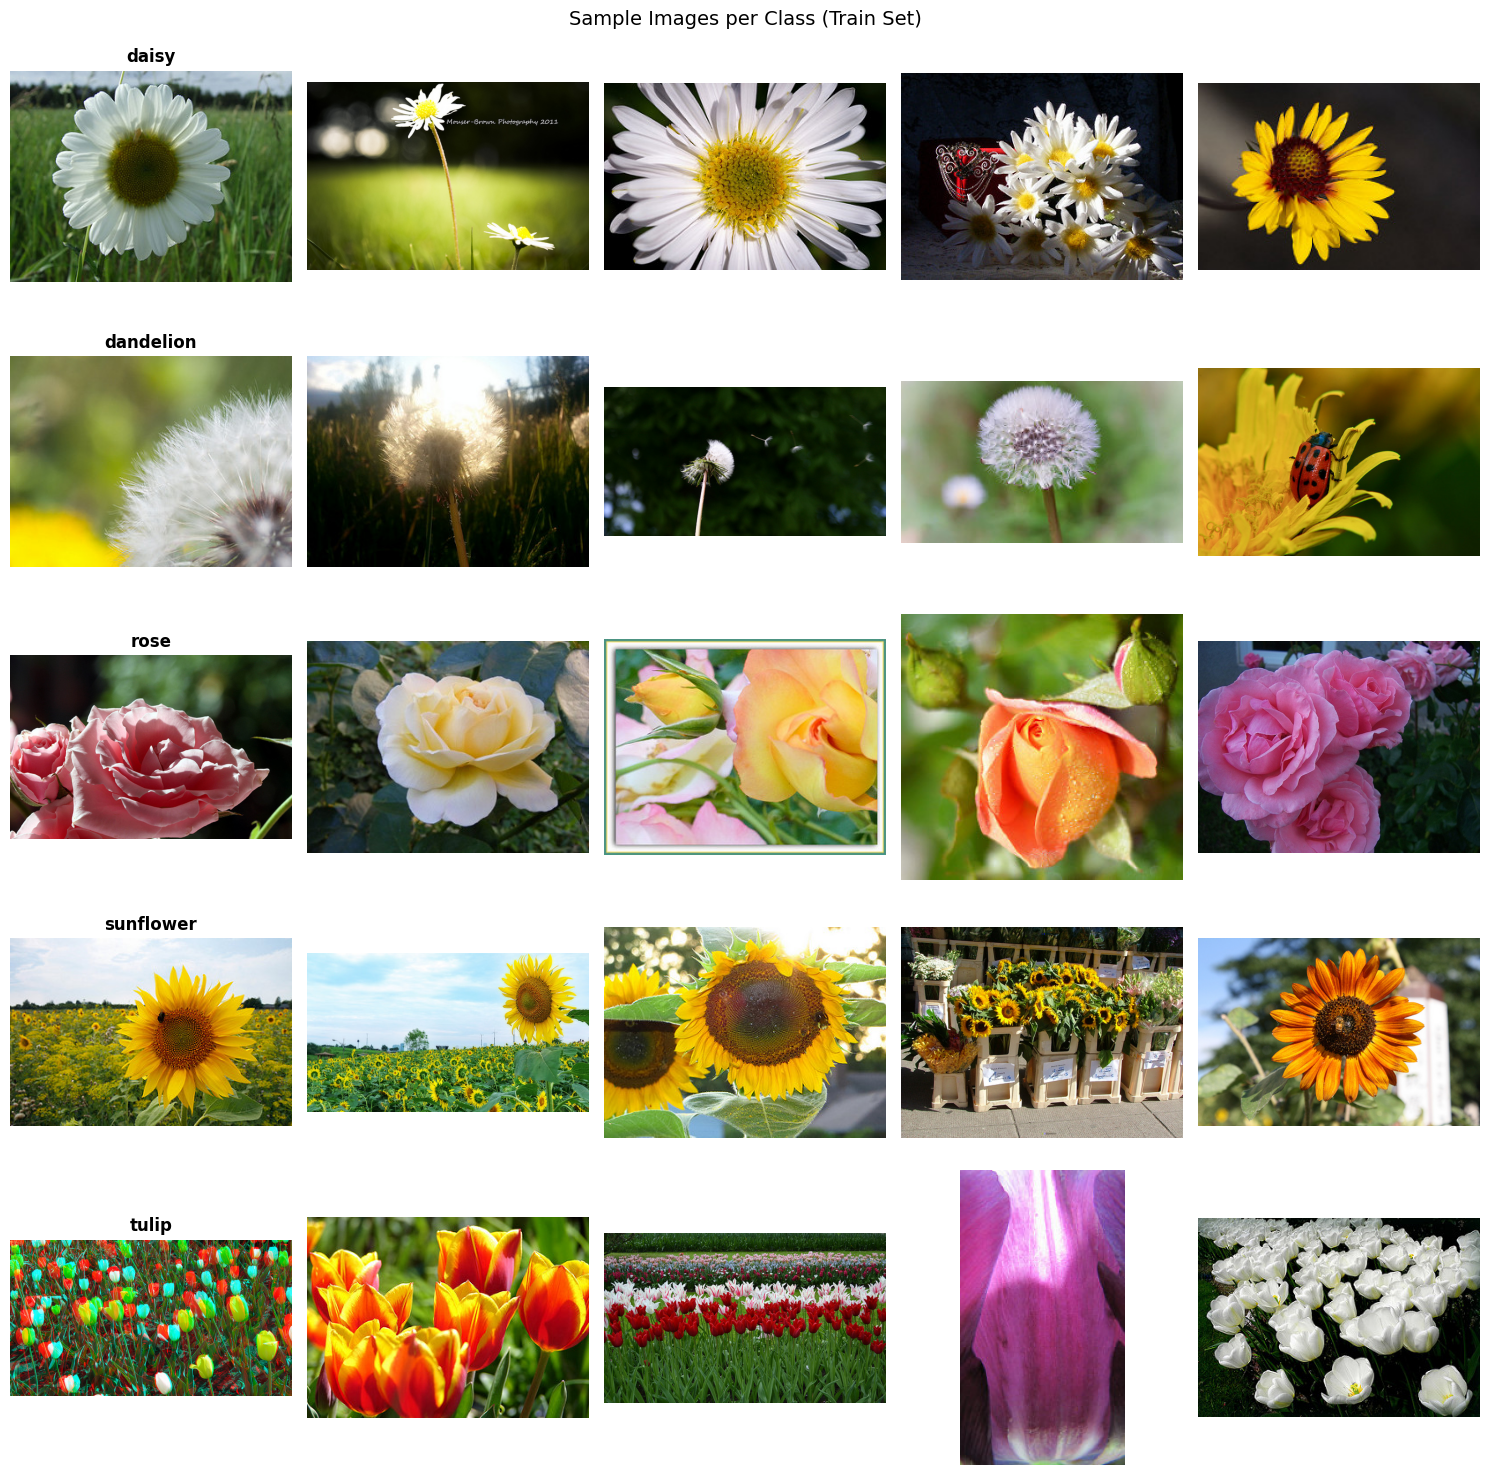

In [ ]:
fig, axes = plt.subplots(len(classes), 5, figsize=(15, len(classes) * 3))

for row, cls in enumerate(classes):
    cls_path = os.path.join(base_path, "train", cls)
    imgs = os.listdir(cls_path)[:5]
    for col, img_name in enumerate(imgs):
        img = mpimg.imread(os.path.join(cls_path, img_name))
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_title(cls, fontsize=12, fontweight='bold')

plt.suptitle("Sample Images per Class (Train Set)", fontsize=14)
plt.tight_layout()
plt.show()

**Augmented Images**

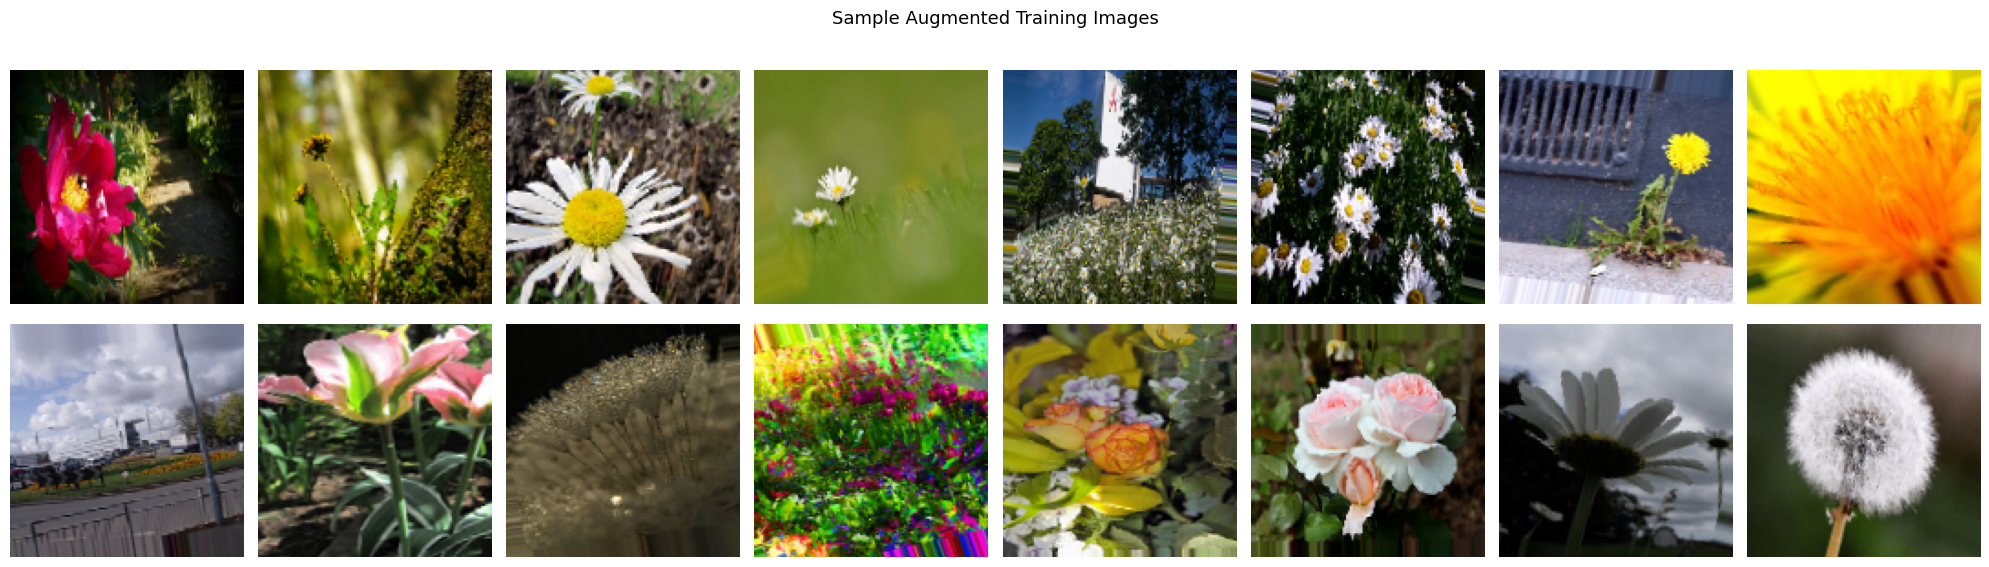

In [ ]:
import numpy as np

sample_batch_imgs, _ = next(train_gen)

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_batch_imgs[i])
    ax.axis('off')

plt.suptitle("Sample Augmented Training Images", fontsize=13)
plt.tight_layout()
plt.show()

**Building Baseline CNN Model**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

baseline_model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),

    # Block 2
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2, 2),

    # Block 3
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2, 2),

    # Fully Connected Layers
    Flatten(),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64,  activation='relu'),

    # Output
    Dense(5, activation='softmax')
])

baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,557,509 (25.01 MB)

 Trainable params: 6,557,509 (25.01 MB)

 Non-trainable params: 0 (0.00 B)

**Train the model**

In [ ]:
import time

start = time.time()

history_baseline = baseline_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25
)

baseline_time = time.time() - start
print(f"\nBaseline training time: {baseline_time:.2f} seconds")

Epoch 1/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 32s 257ms/step - accuracy: 0.4055 - loss: 1.3500 - val_accuracy: 0.5525 - val_loss: 1.0976
Epoch 2/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 19s 196ms/step - accuracy: 0.5511 - loss: 1.1213 - val_accuracy: 0.5941 - val_loss: 1.0226
Epoch 3/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 218ms/step - accuracy: 0.6071 - loss: 0.9956 - val_accuracy: 0.6373 - val_loss: 0.9401
Epoch 4/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 18s 193ms/step - accuracy: 0.6557 - loss: 0.8985 - val_accuracy: 0.6065 - val_loss: 1.0355
Epoch 5/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 19s 202ms/step - accuracy: 0.6849 - loss: 0.8317 - val_accuracy: 0.6759 - val_loss: 0.8730
Epoch 6/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 18s 193ms/step - accuracy: 0.6912 - loss: 0.7868 - val_accuracy: 0.6574 - val_loss: 0.9085
Epoch 7/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 20s 207ms/step - accuracy: 0.7027 - loss: 0.7674 - val_accuracy: 0.6713 - val_loss: 0.8584
Epoch 8/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 19s 195ms/step - accuracy: 0.7253 - loss: 0.7260 - val_accu

**Plotloss & Accuracy Curves**

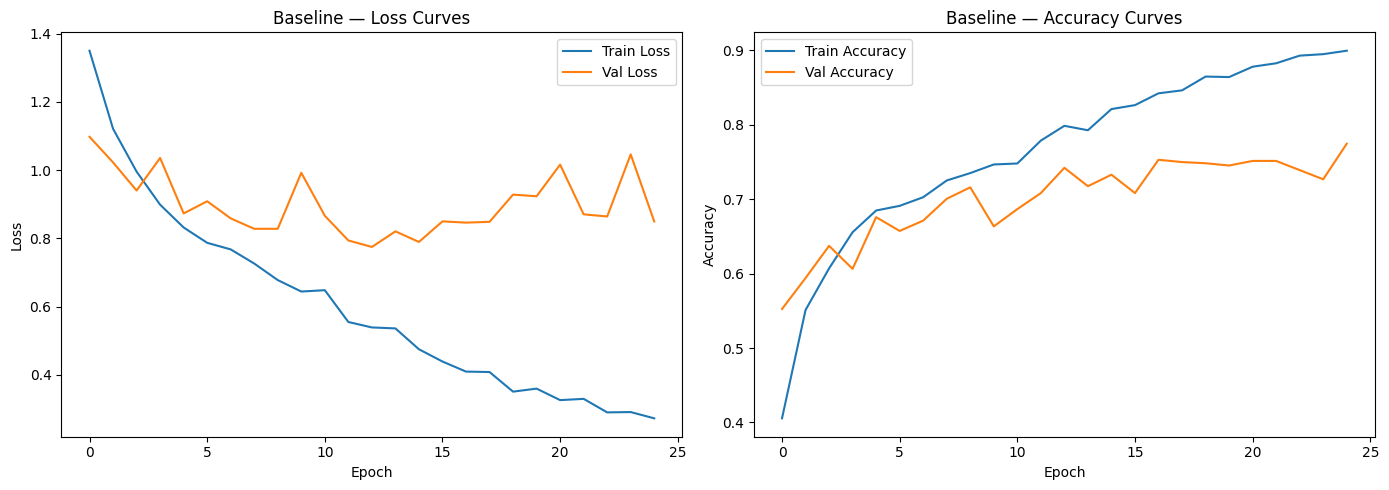

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history_baseline.history['loss'],     label='Train Loss')
axes[0].plot(history_baseline.history['val_loss'], label='Val Loss')
axes[0].set_title("Baseline — Loss Curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Accuracy
axes[1].plot(history_baseline.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history_baseline.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title("Baseline — Accuracy Curves")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

**Evaluate on Test Set**

21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step
=== Baseline Model — Test Set Evaluation ===

              precision    recall  f1-score   support

       daisy       0.78      0.73      0.75       114
   dandelion       0.78      0.88      0.83       158
        rose       0.66      0.64      0.65       118
   sunflower       0.77      0.83      0.80       110
       tulip       0.74      0.66      0.70       148

    accuracy                           0.75       648
   macro avg       0.75      0.75      0.74       648
weighted avg       0.75      0.75      0.75       648



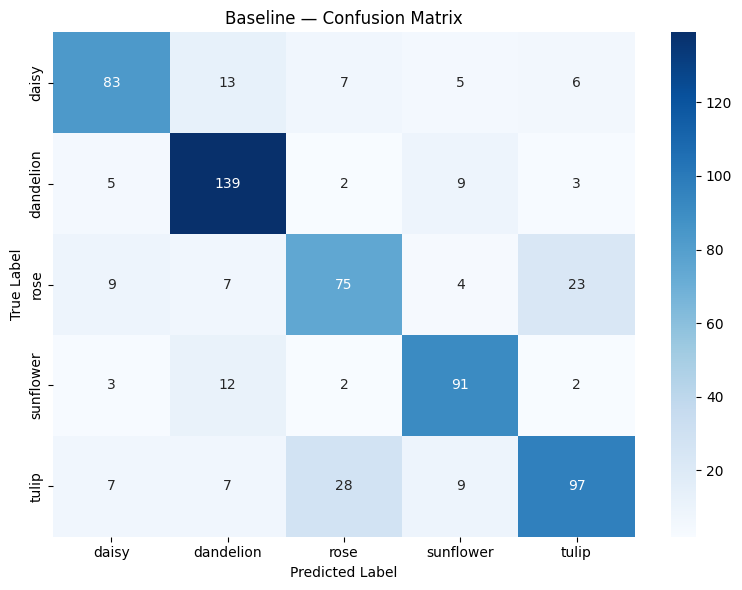

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

test_gen.reset()
preds = baseline_model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)
y_true = test_gen.classes

print("=== Baseline Model — Test Set Evaluation ===\n")
print(classification_report(y_true, y_pred, target_names=classes))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title("Baseline — Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()


**Sample Predictions**

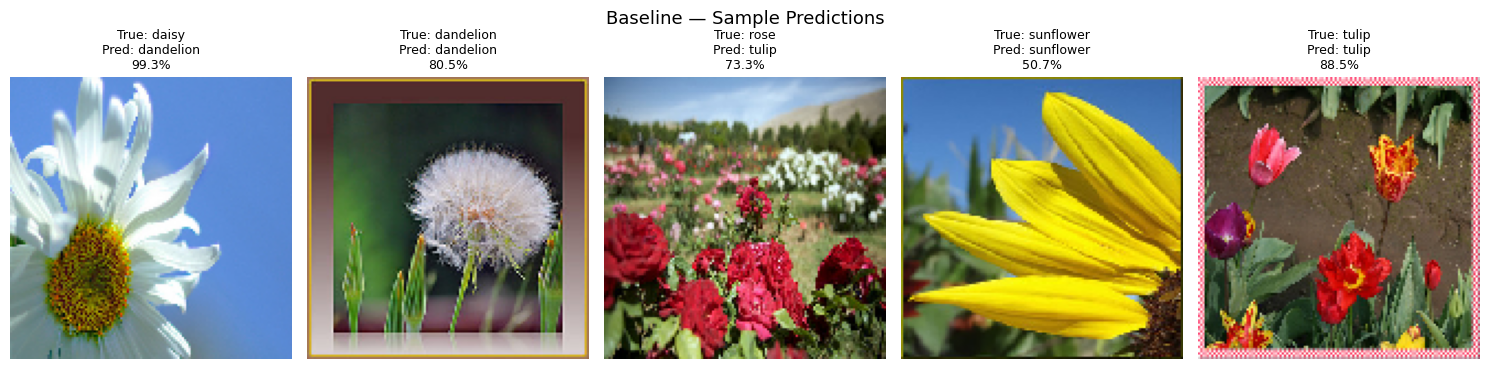

In [ ]:
from tensorflow.keras.preprocessing import image

def predict_and_show(model, img_path, class_names):
    img = image.load_img(img_path, target_size=(128, 128))
    x   = image.img_to_array(img) / 255.0
    x   = np.expand_dims(x, axis=0)
    pred = model.predict(x, verbose=0)
    label = class_names[np.argmax(pred)]
    confidence = np.max(pred) * 100
    plt.imshow(img)
    plt.title(f"Predicted: {label} ({confidence:.1f}%)")
    plt.axis('off')
    plt.show()

# Run on one sample from each class
fig = plt.figure(figsize=(15, 4))
for i, cls in enumerate(classes):
    cls_path = os.path.join(base_path, "test", cls)
    img_path = os.path.join(cls_path, os.listdir(cls_path)[0])
    plt.subplot(1, 5, i+1)
    img = image.load_img(img_path, target_size=(128,128))
    x   = image.img_to_array(img) / 255.0
    pred = baseline_model.predict(np.expand_dims(x, 0), verbose=0)
    label = classes[np.argmax(pred)]
    conf  = np.max(pred) * 100
    plt.imshow(img)
    plt.title(f"True: {cls}\nPred: {label}\n{conf:.1f}%", fontsize=9)
    plt.axis('off')

plt.suptitle("Baseline — Sample Predictions", fontsize=13)
plt.tight_layout()
plt.show()

**Deeper Model**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten,
                                     Dense, Dropout, BatchNormalization)

deeper_model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128, 128, 3)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Block 4
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Fully Connected Layers
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),

    # Output
    Dense(5, activation='softmax')
])

deeper_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

deeper_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,04

 Total params: 9,730,213 (37.12 MB)

 Trainable params: 9,728,229 (37.11 MB)

 Non-trainable params: 1,984 (7.75 KB)

**Train The Deeper Model**

In [ ]:
import time

start = time.time()

history_deeper = deeper_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30
)

deeper_time = time.time() - start
print(f"\nDeeper model training time: {deeper_time:.2f} seconds")
print(f"Baseline training time:     {baseline_time:.2f} seconds")

Epoch 1/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 59s 397ms/step - accuracy: 0.4019 - loss: 1.4892 - val_accuracy: 0.2438 - val_loss: 2.5394
Epoch 2/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 221ms/step - accuracy: 0.5028 - loss: 1.2241 - val_accuracy: 0.2438 - val_loss: 2.2738
Epoch 3/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 20s 213ms/step - accuracy: 0.5382 - loss: 1.1441 - val_accuracy: 0.2438 - val_loss: 2.3350
Epoch 4/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 224ms/step - accuracy: 0.5707 - loss: 1.0644 - val_accuracy: 0.2469 - val_loss: 1.9467
Epoch 5/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 223ms/step - accuracy: 0.6064 - loss: 0.9965 - val_accuracy: 0.3117 - val_loss: 1.9462
Epoch 6/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 215ms/step - accuracy: 0.6365 - loss: 0.9513 - val_accuracy: 0.4660 - val_loss: 1.5032
Epoch 7/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 223ms/step - accuracy: 0.6584 - loss: 0.8812 - val_accuracy: 0.6157 - val_loss: 1.0222
Epoch 8/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 222ms/step - accuracy: 0.6657 - loss: 0.8695 - val_accu

**Plot & Compare Loss Curves (Baseline vs Deeper)**

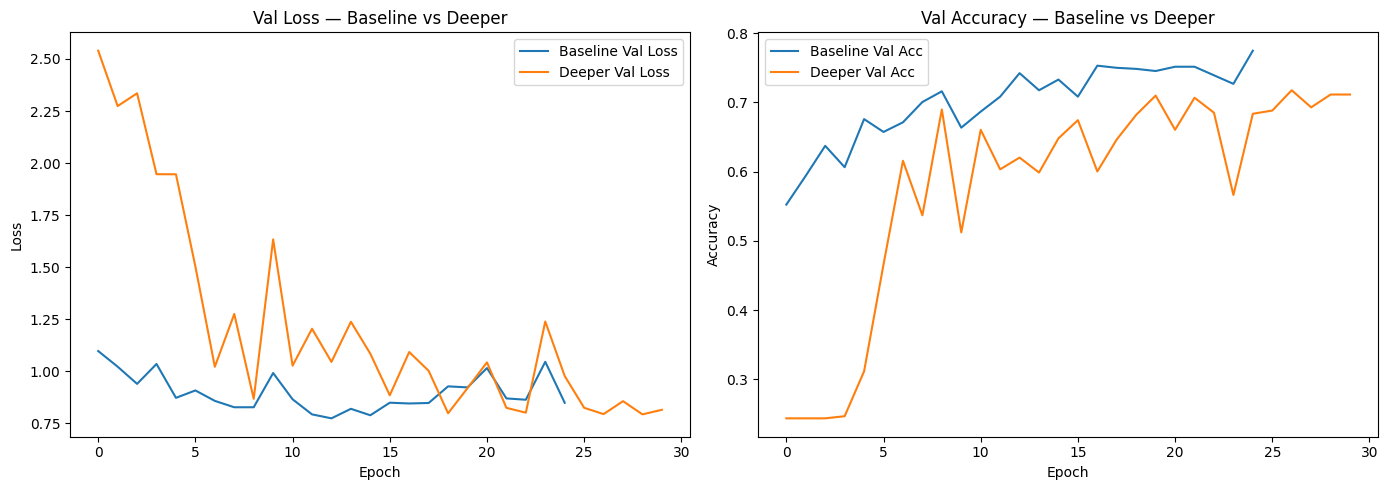

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss comparison
axes[0].plot(history_baseline.history['val_loss'], label='Baseline Val Loss')
axes[0].plot(history_deeper.history['val_loss'],   label='Deeper Val Loss')
axes[0].set_title("Val Loss — Baseline vs Deeper")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Accuracy comparison
axes[1].plot(history_baseline.history['val_accuracy'], label='Baseline Val Acc')
axes[1].plot(history_deeper.history['val_accuracy'],   label='Deeper Val Acc')
axes[1].set_title("Val Accuracy — Baseline vs Deeper")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

**Evaluate Deeper Model on Test Set**

21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step
=== Deeper Model — Test Set Evaluation ===

              precision    recall  f1-score   support

       daisy       0.78      0.70      0.74       114
   dandelion       0.70      0.82      0.76       158
        rose       0.76      0.58      0.66       118
   sunflower       0.66      0.92      0.77       110
       tulip       0.82      0.64      0.71       148

    accuracy                           0.73       648
   macro avg       0.74      0.73      0.73       648
weighted avg       0.74      0.73      0.73       648



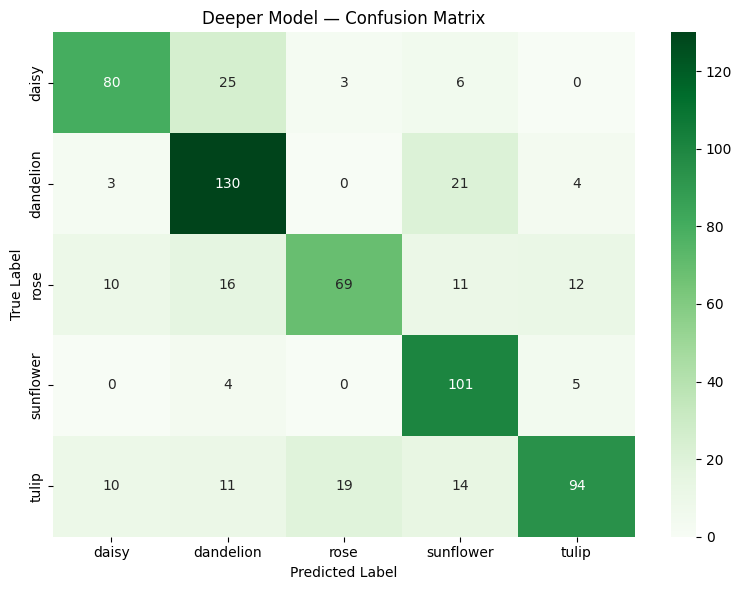

In [ ]:
test_gen.reset()
preds_deeper = deeper_model.predict(test_gen)
y_pred_deeper = np.argmax(preds_deeper, axis=1)
y_true = test_gen.classes

print("=== Deeper Model — Test Set Evaluation ===\n")
print(classification_report(y_true, y_pred_deeper, target_names=classes))

cm_deeper = confusion_matrix(y_true, y_pred_deeper)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_deeper, annot=True, fmt='d', cmap='Greens',
            xticklabels=classes, yticklabels=classes)
plt.title("Deeper Model — Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

**Optimizer Analysis: SGD vs Adam:**

In [ ]:
from tensorflow.keras.optimizers import SGD, Adam

def build_deeper_model():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
        BatchNormalization(),
        Conv2D(32, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2,2), Dropout(0.25),

        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2,2), Dropout(0.25),

        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2,2), Dropout(0.25),

        Conv2D(256, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(256, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2,2), Dropout(0.25),

        Flatten(),
        Dense(512, activation='relu'), BatchNormalization(), Dropout(0.5),
        Dense(256, activation='relu'), Dropout(0.4),
        Dense(128, activation='relu'),
        Dense(5, activation='softmax')
    ])
    return model

# --- Train with SGD ---
model_sgd = build_deeper_model()
model_sgd.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()
history_sgd = model_sgd.fit(train_gen, validation_data=val_gen, epochs=30)
sgd_time = time.time() - start
print(f"SGD training time: {sgd_time:.2f}s")

# --- Train with Adam ---
model_adam = build_deeper_model()
model_adam.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()
history_adam = model_adam.fit(train_gen, validation_data=val_gen, epochs=30)
adam_time = time.time() - start
print(f"Adam training time: {adam_time:.2f}s")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 319ms/step - accuracy: 0.2992 - loss: 1.6397 - val_accuracy: 0.3457 - val_loss: 1.4863
Epoch 2/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 225ms/step - accuracy: 0.3899 - loss: 1.3974 - val_accuracy: 0.3673 - val_loss: 1.4537
Epoch 3/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 22s 235ms/step - accuracy: 0.4614 - loss: 1.2902 - val_accuracy: 0.3704 - val_loss: 1.4247
Epoch 4/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 216ms/step - accuracy: 0.5065 - loss: 1.1799 - val_accuracy: 0.4336 - val_loss: 1.4241
Epoch 5/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 22s 226ms/step - accuracy: 0.5621 - loss: 1.0825 - val_accuracy: 0.5278 - val_loss: 1.2500
Epoch 6/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 224ms/step - accuracy: 0.5763 - loss: 1.0440 - val_accuracy: 0.5370 - val_loss: 1.1680
Epoch 7/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 216ms/step - accuracy: 0.5991 - loss: 0.9903 - val_accuracy: 0.5432 - val_loss: 1.0713
Epoch 8/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 225ms/step - accuracy: 0.5962 - loss: 0.9952 - val_accu

**Comparision SGD VS Adam**

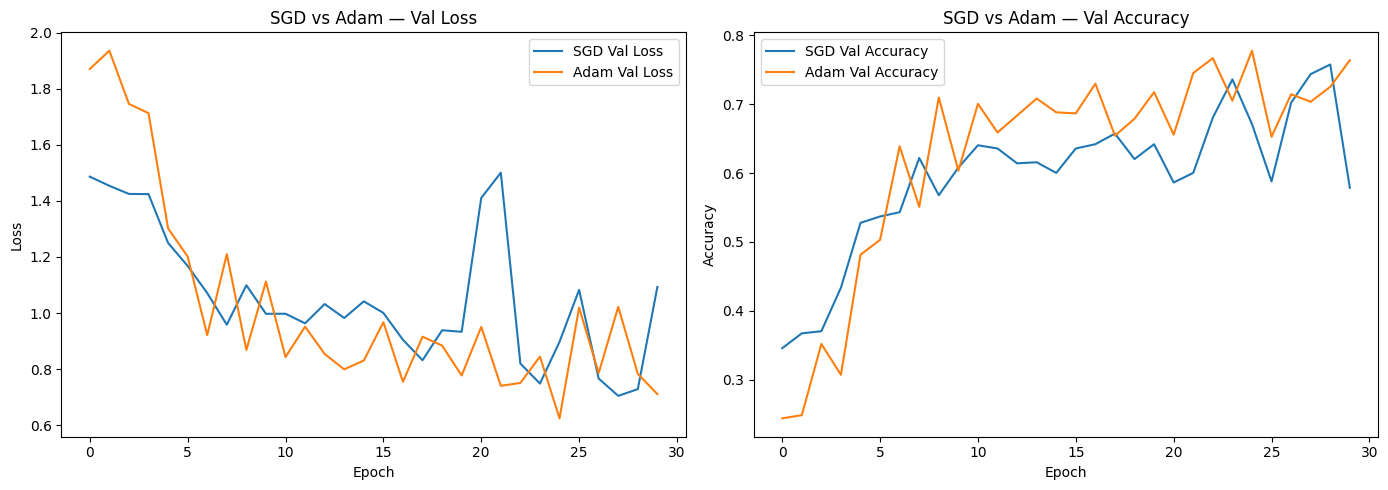

SGD  — Best Val Acc: 0.7577 | Time: 676.68s
Adam — Best Val Acc: 0.7778 | Time: 678.57s


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_sgd.history['val_loss'],  label='SGD Val Loss')
axes[0].plot(history_adam.history['val_loss'], label='Adam Val Loss')
axes[0].set_title("SGD vs Adam — Val Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()

axes[1].plot(history_sgd.history['val_accuracy'],  label='SGD Val Accuracy')
axes[1].plot(history_adam.history['val_accuracy'], label='Adam Val Accuracy')
axes[1].set_title("SGD vs Adam — Val Accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()

plt.tight_layout()
plt.show()

print(f"SGD  — Best Val Acc: {max(history_sgd.history['val_accuracy']):.4f} | Time: {sgd_time:.2f}s")
print(f"Adam — Best Val Acc: {max(history_adam.history['val_accuracy']):.4f} | Time: {adam_time:.2f}s")

**Ablation Study:DropOut Removed**

In [ ]:
def build_no_dropout_model():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
        BatchNormalization(),
        Conv2D(32, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2,2),

        Conv2D(256, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(256, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(512, activation='relu'), BatchNormalization(),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(5, activation='softmax')
    ])
    return model

model_no_dropout = build_no_dropout_model()
model_no_dropout.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_no_dropout = model_no_dropout.fit(
    train_gen, validation_data=val_gen, epochs=30
)

Epoch 1/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 37s 280ms/step - accuracy: 0.5074 - loss: 1.2044 - val_accuracy: 0.2438 - val_loss: 3.1663
Epoch 2/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 20s 214ms/step - accuracy: 0.5664 - loss: 1.0548 - val_accuracy: 0.2438 - val_loss: 3.0267
Epoch 3/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 224ms/step - accuracy: 0.6369 - loss: 0.9428 - val_accuracy: 0.2454 - val_loss: 2.9736
Epoch 4/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 225ms/step - accuracy: 0.6594 - loss: 0.8660 - val_accuracy: 0.3225 - val_loss: 2.3466
Epoch 5/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 216ms/step - accuracy: 0.6819 - loss: 0.8017 - val_accuracy: 0.6065 - val_loss: 1.1292
Epoch 6/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 224ms/step - accuracy: 0.7037 - loss: 0.7667 - val_accuracy: 0.6003 - val_loss: 0.9623
Epoch 7/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 222ms/step - accuracy: 0.7074 - loss: 0.7670 - val_accuracy: 0.6636 - val_loss: 0.8965
Epoch 8/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 20s 209ms/step - accuracy: 0.7299 - loss: 0.7120 - val_accu

**Model Comparision With and Without DropOut**

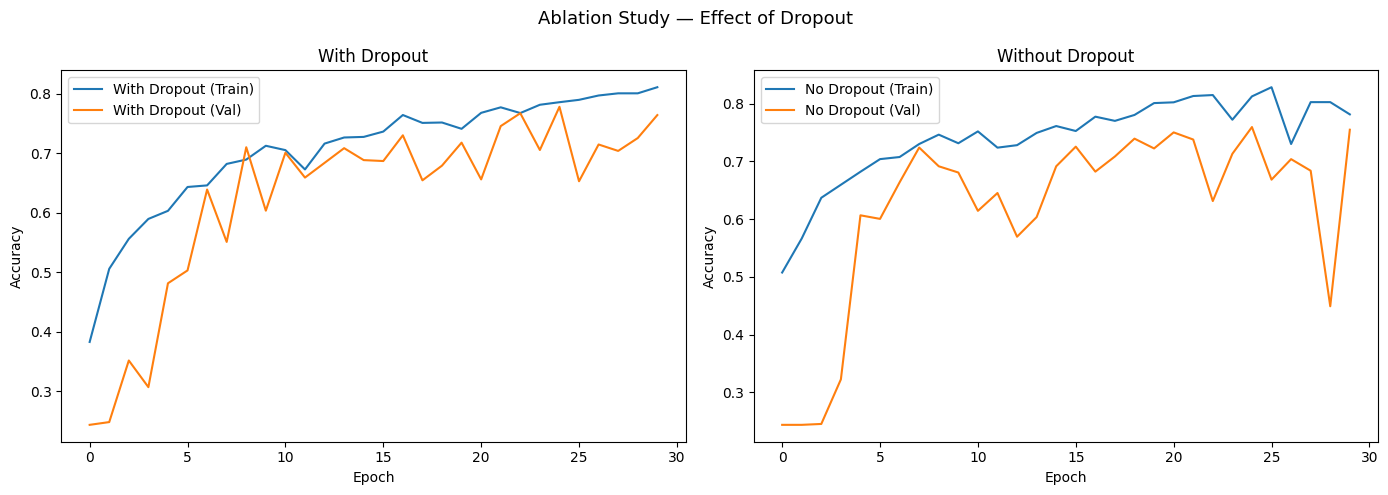

With Dropout    — Best Val Acc: 0.7778
Without Dropout — Best Val Acc: 0.7593


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Compare train vs val accuracy — with and without dropout
axes[0].plot(history_adam.history['accuracy'],     label='With Dropout (Train)')
axes[0].plot(history_adam.history['val_accuracy'], label='With Dropout (Val)')
axes[0].set_title("With Dropout")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy"); axes[0].legend()

axes[1].plot(history_no_dropout.history['accuracy'],     label='No Dropout (Train)')
axes[1].plot(history_no_dropout.history['val_accuracy'], label='No Dropout (Val)')
axes[1].set_title("Without Dropout")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()

plt.suptitle("Ablation Study — Effect of Dropout", fontsize=13)
plt.tight_layout()
plt.show()

print(f"With Dropout    — Best Val Acc: {max(history_adam.history['val_accuracy']):.4f}")
print(f"Without Dropout — Best Val Acc: {max(history_no_dropout.history['val_accuracy']):.4f}")

**Fine-Tuning a pre Trained model**


*    MobileNetV2



**Generating New Data (224x224) for MobileNetV2**

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen_tf = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.15
)
test_val_datagen_tf = ImageDataGenerator(rescale=1./255)

train_gen_tf = train_datagen_tf.flow_from_directory(
    "/content/flowers/train",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=42
)
val_gen_tf = test_val_datagen_tf.flow_from_directory(
    "/content/flowers/val",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
test_gen_tf = test_val_datagen_tf.flow_from_directory(
    "/content/flowers/test",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

Found 3021 images belonging to 5 classes.
Found 648 images belonging to 5 classes.
Found 648 images belonging to 5 classes.


**Load MobileNetV2 With Custom Classification Head**

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization

# Load MobileNetV2 without top classification layer
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,          # Remove ImageNet 1000-class output
    weights='imagenet'          # Use pre-trained ImageNet weights
)

# Freeze entire base for Phase 1
base_model.trainable = False

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(5, activation='softmax')(x)

transfer_model = Model(inputs=base_model.input, outputs=output)

transfer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()
print(f"\nTotal layers: {len(transfer_model.layers)}")
print(f"Trainable layers (Phase 1): {sum(1 for l in transfer_model.layers if l.trainable)}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,620,485 (10.00 MB)

 Trainable params: 361,989 (1.38 MB)

 Non-trainable params: 2,258,496 (8.62 MB)


Total layers: 161
Trainable layers (Phase 1): 7


**Feature Extraction**

In [ ]:
import time

print("=== Phase 1: Feature Extraction (Frozen Base) ===")
start = time.time()

history_phase1 = transfer_model.fit(
    train_gen_tf,
    validation_data=val_gen_tf,
    epochs=10
)

phase1_time = time.time() - start
print(f"Phase 1 training time: {phase1_time:.2f}s")

=== Phase 1: Feature Extraction (Frozen Base) ===
Epoch 1/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 90s 742ms/step - accuracy: 0.7186 - loss: 0.7996 - val_accuracy: 0.8441 - val_loss: 0.4532
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 98s 433ms/step - accuracy: 0.8299 - loss: 0.4932 - val_accuracy: 0.8596 - val_loss: 0.4085
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 434ms/step - accuracy: 0.8467 - loss: 0.4233 - val_accuracy: 0.8858 - val_loss: 0.3743
Epoch 4/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 42s 441ms/step - accuracy: 0.8590 - loss: 0.3912 - val_accuracy: 0.8673 - val_loss: 0.4023
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 429ms/step - accuracy: 0.8716 - loss: 0.3539 - val_accuracy: 0.8781 - val_loss: 0.3797
Epoch 6/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 427ms/step - accuracy: 0.8832 - loss: 0.3372 - val_accuracy: 0.8765 - val_loss: 0.3845
Epoch 7/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 426ms/step - accuracy: 0.8971 - loss: 0.2996 - val_accuracy: 0.8796 - val_loss: 0.3690
Epoch 8/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 432ms

**Fine Tuning**

In [ ]:
import tensorflow as tf

print("=== Phase 2: Fine-Tuning (Unfreeze Last 30 Layers) ===")

# Unfreeze the base model
base_model.trainable = True

# Freeze all layers EXCEPT the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

print(f"Trainable layers (Phase 2): {sum(1 for l in transfer_model.layers if l.trainable)}")

# Recompile with a MUCH lower learning rate to avoid catastrophic forgetting
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()
history_phase2 = transfer_model.fit(
    train_gen_tf,
    validation_data=val_gen_tf,
    epochs=10
)
phase2_time = time.time() - start
print(f"Phase 2 training time: {phase2_time:.2f}s")
print(f"Total transfer learning time: {phase1_time + phase2_time:.2f}s")

=== Phase 2: Fine-Tuning (Unfreeze Last 30 Layers) ===
Trainable layers (Phase 2): 37
Epoch 1/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 80s 633ms/step - accuracy: 0.8213 - loss: 0.5102 - val_accuracy: 0.8781 - val_loss: 0.3813
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 42s 442ms/step - accuracy: 0.8653 - loss: 0.3890 - val_accuracy: 0.8812 - val_loss: 0.4113
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 42s 446ms/step - accuracy: 0.8745 - loss: 0.3444 - val_accuracy: 0.8781 - val_loss: 0.4287
Epoch 4/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 42s 442ms/step - accuracy: 0.8851 - loss: 0.3263 - val_accuracy: 0.8781 - val_loss: 0.4199
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 42s 440ms/step - accuracy: 0.8878 - loss: 0.3063 - val_accuracy: 0.8827 - val_loss: 0.4058
Epoch 6/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 42s 437ms/step - accuracy: 0.8974 - loss: 0.2704 - val_accuracy: 0.8858 - val_loss: 0.3956
Epoch 7/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 43s 450ms/step - accuracy: 0.9027 - loss: 0.2686 - val_accuracy: 0.8951 - val_loss: 0.3820
Epoch 8/10


**Loss & Accuracy Curves**

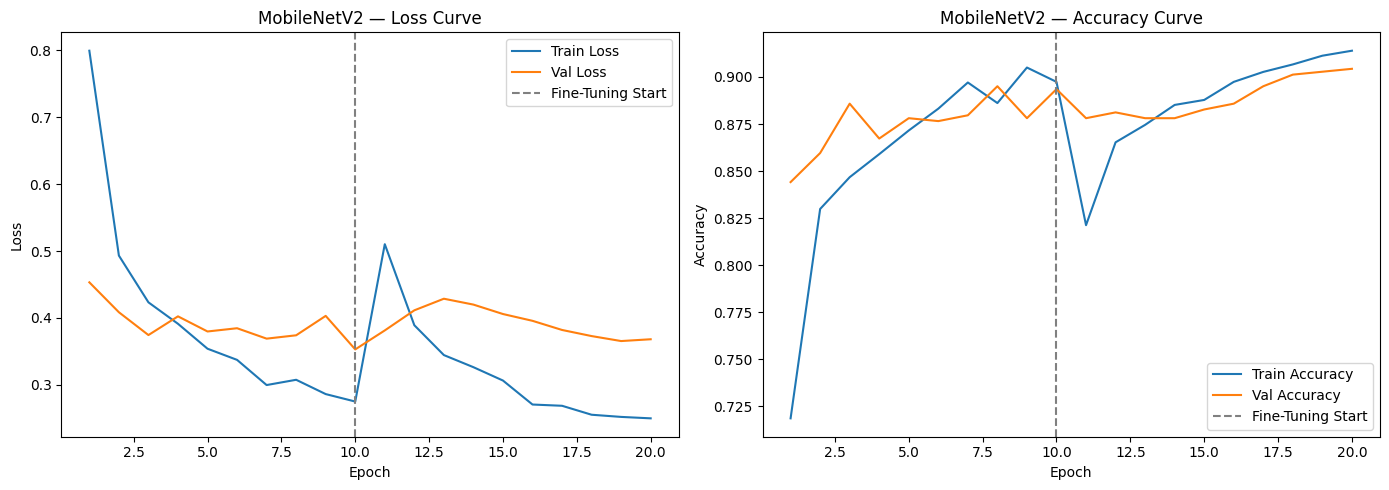

In [ ]:
acc1  = history_phase1.history['accuracy']
vacc1 = history_phase1.history['val_accuracy']
acc2  = history_phase2.history['accuracy']
vacc2 = history_phase2.history['val_accuracy']

all_acc  = acc1  + acc2
all_vacc = vacc1 + vacc2
epochs   = range(1, len(all_acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history_phase1.history['loss'] + history_phase2.history['loss'], label='Train Loss')
axes[0].plot(epochs, history_phase1.history['val_loss'] + history_phase2.history['val_loss'], label='Val Loss')
axes[0].axvline(x=10, color='gray', linestyle='--', label='Fine-Tuning Start')
axes[0].set_title("MobileNetV2 — Loss Curve")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()

axes[1].plot(epochs, all_acc,  label='Train Accuracy')
axes[1].plot(epochs, all_vacc, label='Val Accuracy')
axes[1].axvline(x=10, color='gray', linestyle='--', label='Fine-Tuning Start')
axes[1].set_title("MobileNetV2 — Accuracy Curve")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()

plt.tight_layout()
plt.show()

**Evaluation On Test Set**

21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 288ms/step
=== MobileNetV2 Transfer Learning — Test Set Evaluation ===

              precision    recall  f1-score   support

       daisy       0.90      0.87      0.88       114
   dandelion       0.90      0.96      0.93       158
        rose       0.83      0.86      0.85       118
   sunflower       0.94      0.86      0.90       110
       tulip       0.88      0.88      0.88       148

    accuracy                           0.89       648
   macro avg       0.89      0.89      0.89       648
weighted avg       0.89      0.89      0.89       648



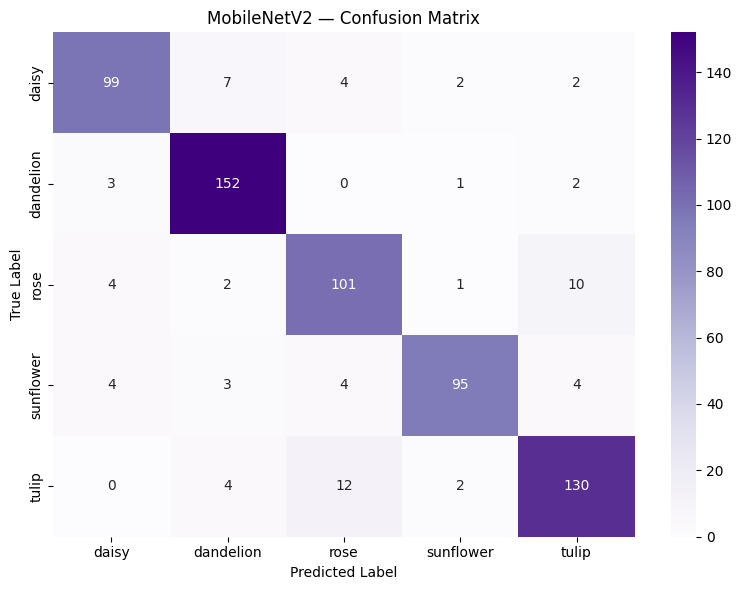


===== FINAL COMPARISON — Part A vs Part B =====
Baseline CNN         — Test Acc: 0.77 | Time: 474.78s
Deeper CNN (Adam)    — Test Acc: 0.77 | Time: 685.68s
MobileNetV2 Transfer — Test Acc: 0.8904 | Time: 979.39s


In [ ]:
test_gen_tf.reset()
preds_tf = transfer_model.predict(test_gen_tf)
y_pred_tf = np.argmax(preds_tf, axis=1)
y_true_tf = test_gen_tf.classes

print("=== MobileNetV2 Transfer Learning — Test Set Evaluation ===\n")
print(classification_report(y_true_tf, y_pred_tf, target_names=classes))

cm_tf = confusion_matrix(y_true_tf, y_pred_tf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tf, annot=True, fmt='d', cmap='Purples',
            xticklabels=classes, yticklabels=classes)
plt.title("MobileNetV2 — Confusion Matrix")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

# Final comparison
print("\n===== FINAL COMPARISON — Part A vs Part B =====")
print(f"Baseline CNN         — Test Acc: 0.77 | Time: 474.78s")
print(f"Deeper CNN (Adam)    — Test Acc: 0.77 | Time: 685.68s")
print(f"MobileNetV2 Transfer — Test Acc: {transfer_model.evaluate(test_gen_tf, verbose=0)[1]:.4f} | Time: {phase1_time+phase2_time:.2f}s")

**Sample Predictions — All Models Side by Side (Baseline, Deeper, MobileNetV2)**

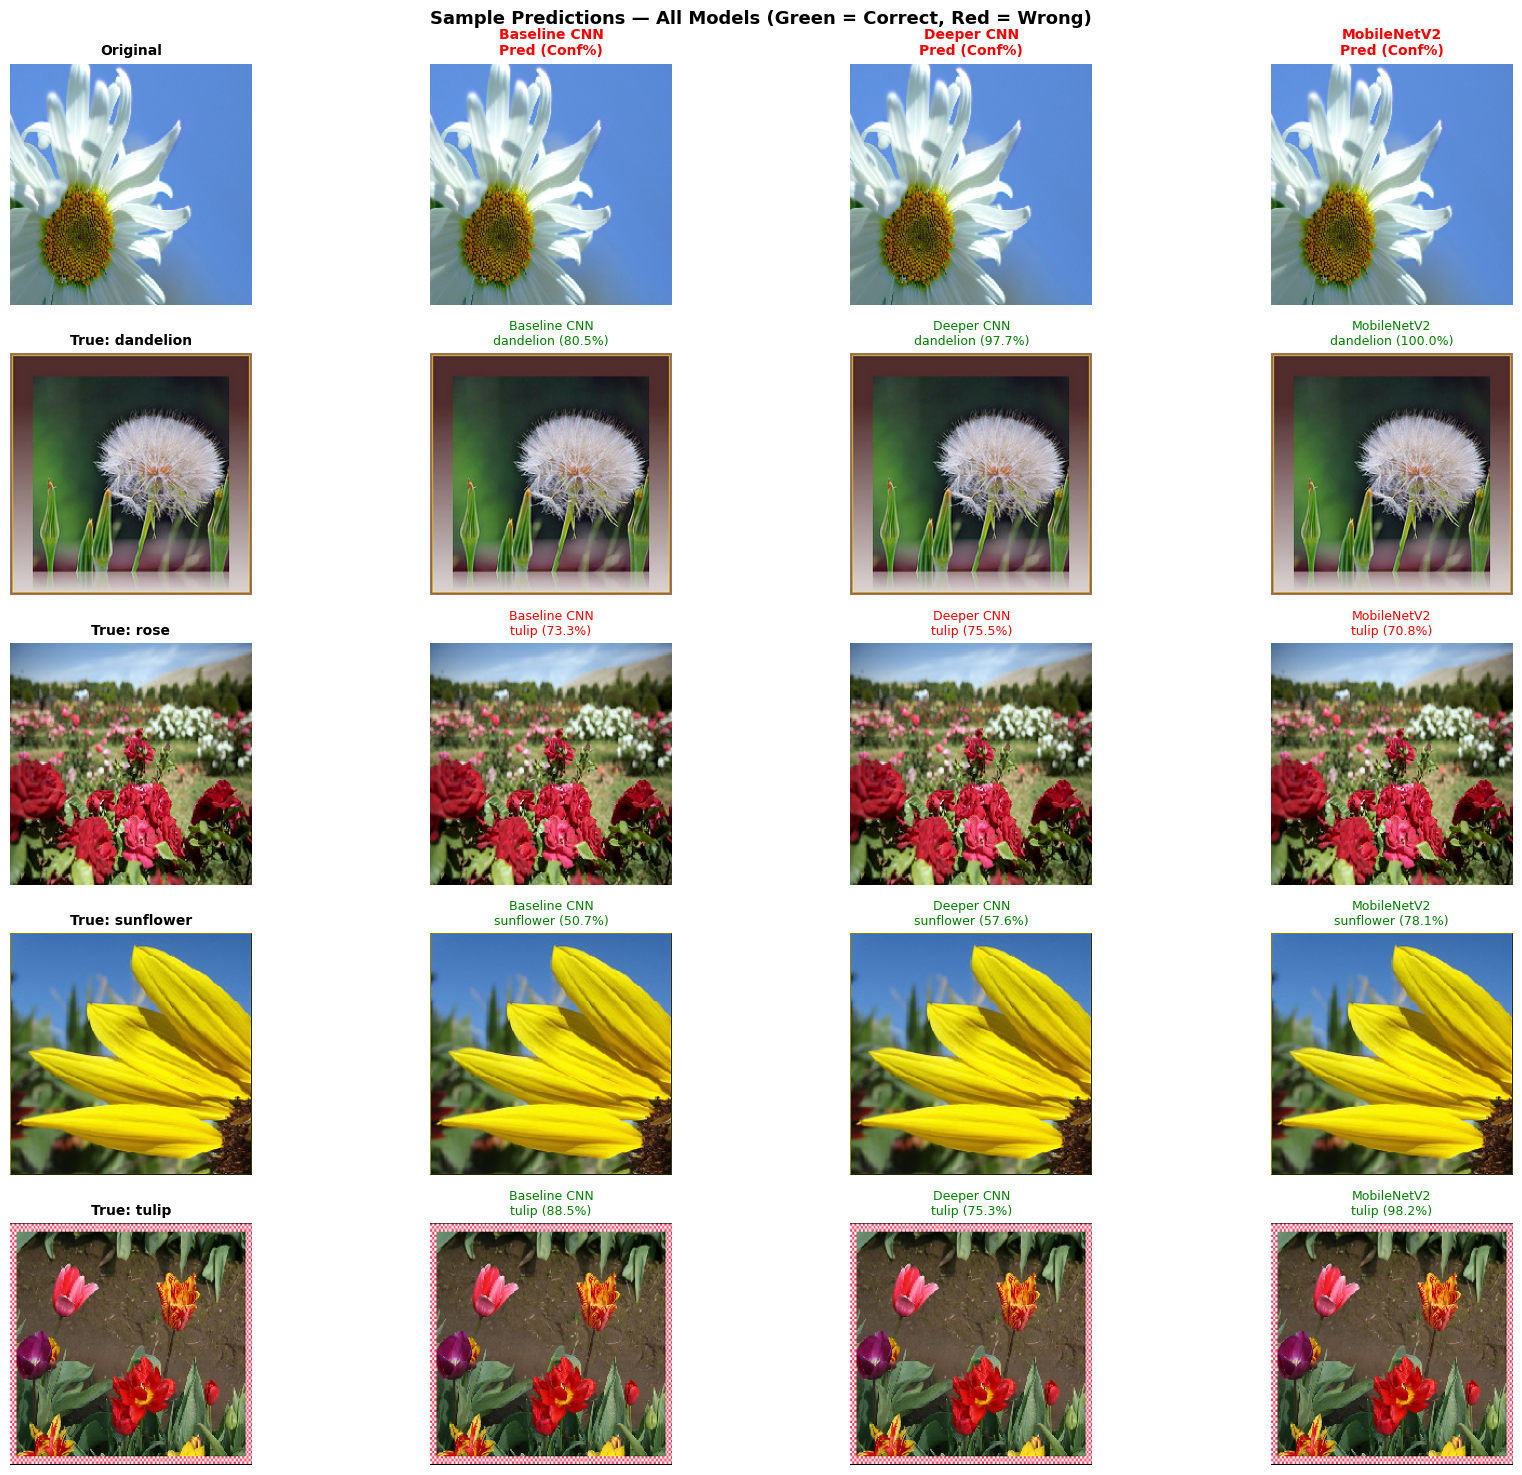

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import os

def get_sample_images(test_path, classes, n=1):
    samples = []
    for cls in classes:
        cls_path = os.path.join(test_path, cls)
        img_name = os.listdir(cls_path)[0]
        samples.append((os.path.join(cls_path, img_name), cls))
    return samples

def predict_all_models(img_path, models, model_names, class_names, img_sizes):
    results = []
    for model, size in zip(models, img_sizes):
        img = image.load_img(img_path, target_size=size)
        x   = image.img_to_array(img) / 255.0
        x   = np.expand_dims(x, axis=0)
        pred = model.predict(x, verbose=0)
        label = class_names[np.argmax(pred)]
        conf  = np.max(pred) * 100
        results.append((label, conf))
    return results

# Setup
test_path  = "/content/flowers/test"
classes    = sorted(os.listdir(test_path))
samples    = get_sample_images(test_path, classes)

models      = [baseline_model, deeper_model, transfer_model]
model_names = ["Baseline CNN", "Deeper CNN", "MobileNetV2"]
img_sizes   = [(128, 128), (128, 128), (224, 224)]

# Plot
fig, axes = plt.subplots(len(classes), len(models) + 1, figsize=(18, len(classes) * 3))

for row, (img_path, true_label) in enumerate(samples):
    # Show original image in first column
    img_display = image.load_img(img_path, target_size=(224, 224))
    axes[row][0].imshow(img_display)
    axes[row][0].set_title(f"True: {true_label}", fontsize=10, fontweight='bold')
    axes[row][0].axis('off')

    # Predictions from each model
    results = predict_all_models(img_path, models, model_names, classes, img_sizes)
    for col, (model_name, (pred_label, conf)) in enumerate(zip(model_names, results)):
        axes[row][col + 1].imshow(img_display)
        color = 'green' if pred_label == true_label else 'red'
        axes[row][col + 1].set_title(
            f"{model_name}\n{pred_label} ({conf:.1f}%)",
            fontsize=9, color=color
        )
        axes[row][col + 1].axis('off')

# Column headers
col_headers = ["Original"] + model_names
for col, header in enumerate(col_headers):
    axes[0][col].set_title(
        header if col == 0 else f"{header}\nPred (Conf%)",
        fontsize=10, fontweight='bold',
        color='black' if col == 0 else
              ('green' if results[col-1][0] == samples[0][1] else 'red')
    )

plt.suptitle("Sample Predictions — All Models (Green = Correct, Red = Wrong)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()